# 🛡️ Detección de Fraude en Reclamos de Seguros

Este proyecto realiza un **Análisis Exploratorio de Datos (EDA)** y desarrolla un **Modelo de Machine Learning** predictivo utilizando un dataset de reclamos de seguros de automóviles. 

El objetivo principal es identificar patrones característicos de los reclamos fraudulentos y entrenar un clasificador capaz de predecir el fraude de manera proactiva, ayudando a las aseguradoras a mitigar pérdidas financieras y optimizar sus procesos de auditoría.

### 📋 Estructura del Notebook:
1. **Preparación y Carga de Datos**: Configuración del entorno y carga del dataset.
2. **Análisis de la Variable Target**: Evaluación de la proporción de fraudes (desbalanceo de clases).
3. **Análisis Exploratorio de Datos (EDA)**: Relación del fraude con la gravedad del incidente, montos de reclamos y demografía.
4. **Ingeniería de Features y Preparación para ML**: Codificación de variables categóricas e imputación.
5. **Desarrollo de Modelos de Machine Learning**: Entrenamiento de un modelo *Random Forest Classifier*.
6. **Evaluación de Métricas y Feature Importance**: Análisis de qué variables influyen más en el fraude.

## 1. Preparación y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder

# Configuración estética de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Cargar el dataset (ejecutar el notebook desde la raíz del repositorio)
df = pd.read_csv("cleaned_insurance_claims.csv")

# Orden fijo de la variable target para que colores y leyendas sean consistentes en todos los gráficos
FRAUD_ORDER = ["N", "Y"]
FRAUD_LABELS = ["No (N)", "Sí (Y)"]

# Mostrar dimensiones y las primeras filas
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 1000 filas, 40 columnas


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## 2. Análisis de la Variable Target (`fraud_reported`)

Antes de realizar análisis cruzados, es fundamental entender la distribución de nuestra variable objetivo. La detección de fraude suele caracterizarse por un desbalance de clases (los fraudes representan una minoría de los casos).

Clase N: 753 reclamos (75.30%)
Clase Y: 247 reclamos (24.70%)


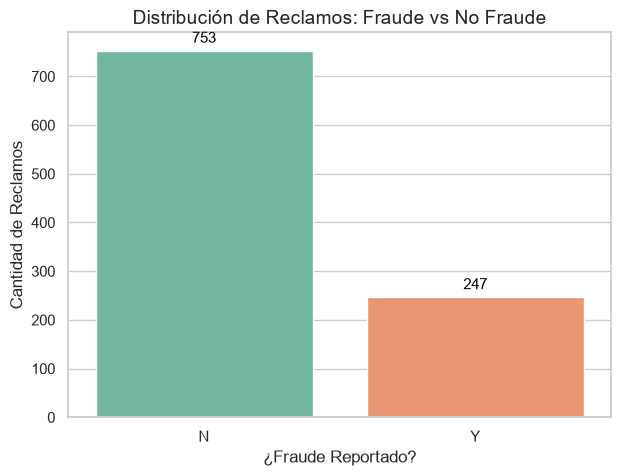

In [2]:
# Distribución de frecuencias
target_counts = df["fraud_reported"].value_counts()
target_pct = df["fraud_reported"].value_counts(normalize=True) * 100

for idx in target_counts.index:
    print(f"Clase {idx}: {target_counts[idx]} reclamos ({target_pct[idx]:.2f}%)")

# Gráfico de barras de desbalanceo de clases
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="fraud_reported", data=df, hue="fraud_reported", order=FRAUD_ORDER,
                   hue_order=FRAUD_ORDER, palette="Set2", legend=False)
plt.title("Distribución de Reclamos: Fraude vs No Fraude")
plt.xlabel("¿Fraude Reportado?")
plt.ylabel("Cantidad de Reclamos")

# Añadir valores arriba de las barras
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height() + 10), 
                ha="center", va="center", fontsize=11, color="black", xytext=(0, 5), textcoords="offset points")
plt.show()

* **Observación:** Aproximadamente el **24.7%** de los reclamos están etiquetados como fraude (`Y`), mientras que el **75.3%** son legítimos (`N`). Existe un desbalanceo moderado, el cual tendremos en cuenta al evaluar el modelo de Machine Learning utilizando métricas robustas como F1-Score y ROC-AUC.

## 3. Análisis Exploratorio de Datos (EDA)

Analizaremos cómo se relacionan diversas variables categóricas y numéricas con la probabilidad de fraude.

### A. Gravedad y Tipo de Incidente vs Fraude
¿Influye la severidad del accidente en la probabilidad de que se cometa un fraude?

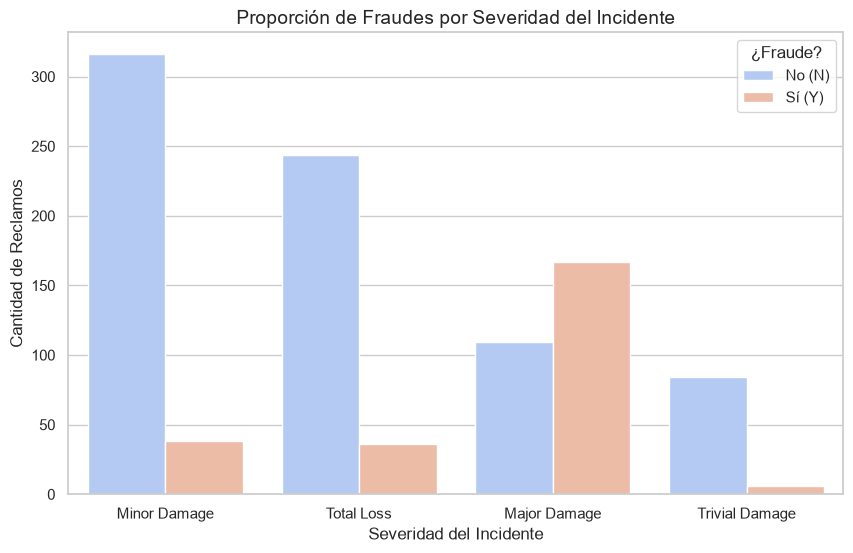

Tasa de fraude por severidad del incidente (%):
incident_severity
Major Damage      60.5
Total Loss        12.9
Minor Damage      10.7
Trivial Damage     6.7
Name: fraud_reported, dtype: float64


In [3]:
# Tabla cruzada de Severidad del Incidente vs Fraude
plt.figure(figsize=(10, 6))
ax = sns.countplot(x="incident_severity", hue="fraud_reported", hue_order=FRAUD_ORDER, data=df, palette="coolwarm",
                   order=df["incident_severity"].value_counts().index)
plt.title("Proporción de Fraudes por Severidad del Incidente")
plt.xlabel("Severidad del Incidente")
plt.ylabel("Cantidad de Reclamos")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, FRAUD_LABELS, title="¿Fraude?")
plt.show()

# Tasa de fraude por severidad (en %)
fraud_rate = (df["fraud_reported"].eq("Y").groupby(df["incident_severity"]).mean() * 100).sort_values(ascending=False)
print("Tasa de fraude por severidad del incidente (%):")
print(fraud_rate.round(1))

* **Observación Clave:** Los incidentes clasificados como **Major Damage** (Daño Mayor) exhiben una tasa de fraude del **60.5%**, frente a 12.9% en *Total Loss*, 10.7% en *Minor Damage* y 6.7% en *Trivial Damage*. Esto sugiere que los reclamos con daños de gran envergadura representan un área de mayor riesgo.

### B. Tipo de Incidente vs Fraude
Veamos qué tipos de incidentes son los más recurrentes.

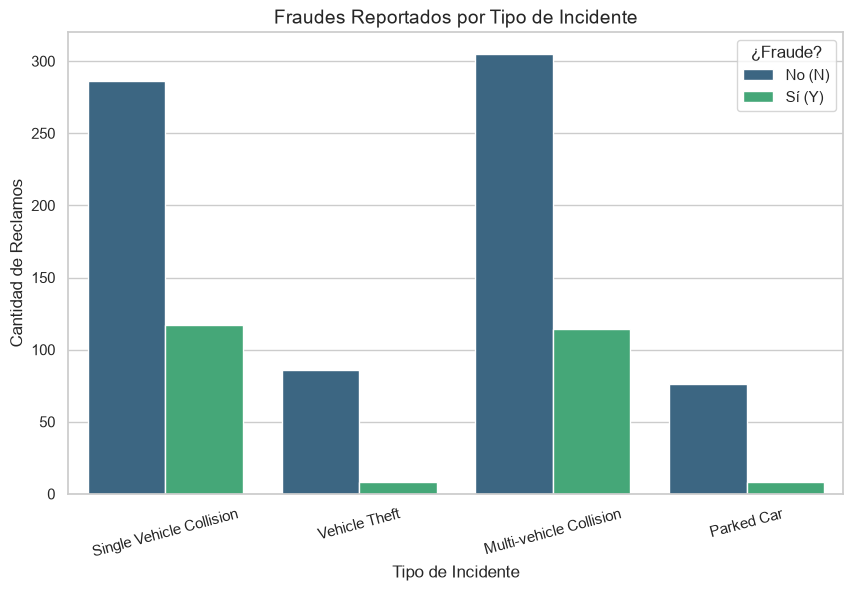

In [4]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x="incident_type", hue="fraud_reported", hue_order=FRAUD_ORDER, data=df, palette="viridis")
plt.title("Fraudes Reportados por Tipo de Incidente")
plt.xlabel("Tipo de Incidente")
plt.ylabel("Cantidad de Reclamos")
plt.xticks(rotation=15)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, FRAUD_LABELS, title="¿Fraude?")
plt.show()

* **Observación:** Los reclamos por **Single Vehicle Collision** y **Multi-vehicle Collision** representan la gran mayoría de los casos y concentran el mayor número de fraudes, mientras que *Vehicle Theft* (Robo) y *Parked Car* muestran menores proporciones.

### C. Montos Reclamados (`total_claim_amount`) según Estado de Fraude
¿Tienen los reclamos fraudulentos un valor reclamado significativamente superior?

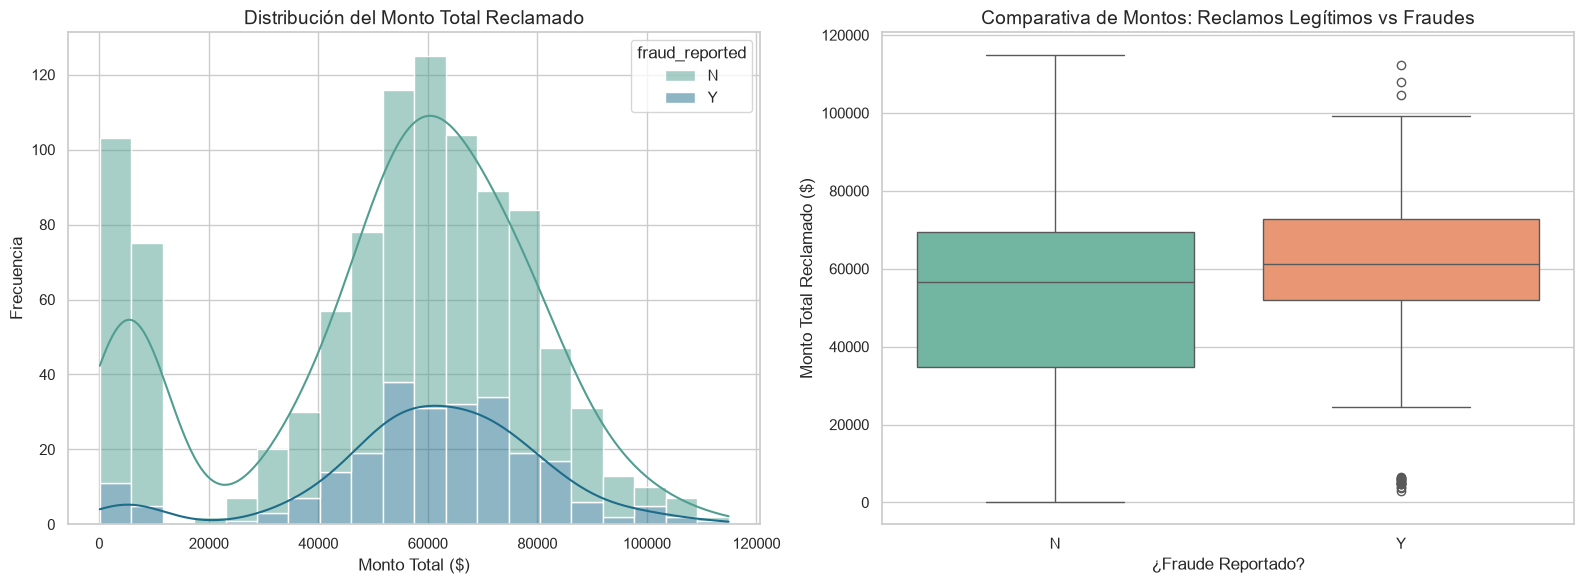

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de distribución general
sns.histplot(ax=axes[0], data=df, x="total_claim_amount", hue="fraud_reported", hue_order=FRAUD_ORDER, kde=True, multiple="stack", palette="crest")
axes[0].set_title("Distribución del Monto Total Reclamado")
axes[0].set_xlabel("Monto Total ($)")
axes[0].set_ylabel("Frecuencia")

# Boxplot comparativo
sns.boxplot(ax=axes[1], x="fraud_reported", y="total_claim_amount", hue="fraud_reported", order=FRAUD_ORDER,
            hue_order=FRAUD_ORDER, data=df, palette="Set2", legend=False)
axes[1].set_title("Comparativa de Montos: Reclamos Legítimos vs Fraudes")
axes[1].set_xlabel("¿Fraude Reportado?")
axes[1].set_ylabel("Monto Total Reclamado ($)")

plt.tight_layout()
plt.show()

* **Observación:** La mayoría de los montos reclamados se agrupan entre los **$40,000 y $80,000**. Los reclamos marcados como fraude tienen una mediana de monto ligeramente superior (≈ $61.300 vs. $56.500) y carecen de reclamos muy bajos, concentrándose en el rango de reclamos de alto valor.

### D. Distribución de Edad según Estado de Fraude
¿Existe algún grupo etario más propenso al fraude?

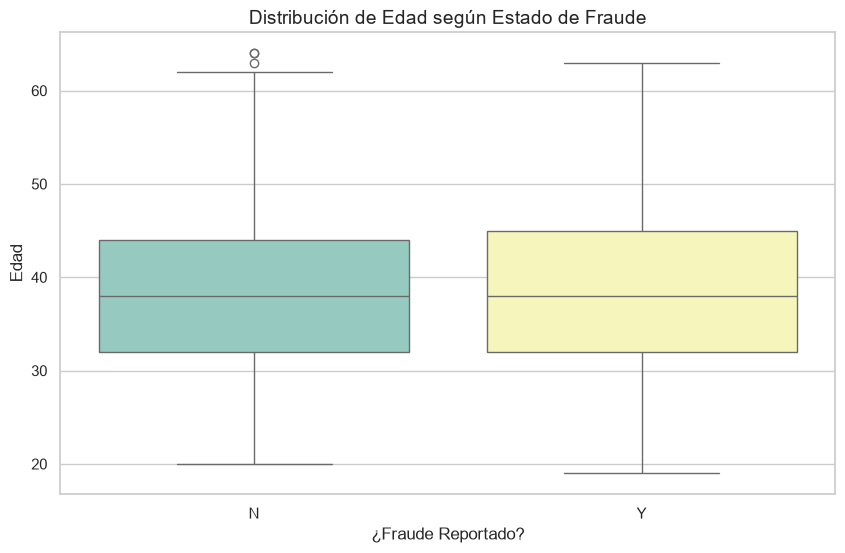

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="fraud_reported", y="age", hue="fraud_reported", order=FRAUD_ORDER, hue_order=FRAUD_ORDER,
            data=df, palette="Set3", legend=False)
plt.title("Distribución de Edad según Estado de Fraude")
plt.xlabel("¿Fraude Reportado?")
plt.ylabel("Edad")
plt.show()

* **Observación:** Las distribuciones de edad para reclamos legítimos y fraudulentos son sumamente similares. Esto indica que la edad de manera aislada **no representa un factor predictivo fuerte**, por lo cual necesitaremos modelos multivariables para encontrar interacciones sutiles.

## 4. Ingeniería de Features y Preparación para ML

Para poder entrenar nuestro modelo de Machine Learning, seleccionaremos variables relevantes, codificaremos las variables de texto a números utilizando `LabelEncoder` y limpiaremos posibles columnas inconsistentes.

In [7]:
# 1. Limpieza inicial: Remover columnas irrelevantes o con ruido administrativo alto
cols_to_drop = ['policy_number', 'policy_bind_date', 'insured_zip', 'incident_date', 
                'incident_location', '_c39']
df_ml = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 2. Reemplazo de caracteres nulos implícitos ('?') que tiene el dataset original
df_ml = df_ml.replace('?', np.nan)

# 3. Imputación simple para valores nulos introducidos por los '?'
for col in df_ml.columns:
    if df_ml[col].isnull().any():
        df_ml[col] = df_ml[col].fillna(df_ml[col].mode()[0])

# 4. Codificación de variables categóricas (texto)
le = LabelEncoder()
categorical_cols = df_ml.select_dtypes(exclude='number').columns

for col in categorical_cols:
    # Excluimos la variable target temporalmente de esta transformación directa
    if col != 'fraud_reported':
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Codificar la variable Target: Y -> 1, N -> 0
df_ml['fraud_reported'] = df_ml['fraud_reported'].map({'Y': 1, 'N': 0})

print("✅ Ingeniería de Features y codificación completadas.")
print(f"Dataset final para modelado: {df_ml.shape[1]} variables.")

✅ Ingeniería de Features y codificación completadas.
Dataset final para modelado: 34 variables.


## 5. Desarrollo de Modelos de Machine Learning: *Random Forest Classifier*

Dividiremos los datos en un conjunto de entrenamiento (80%) y testeo (20%) y entrenaremos un modelo Random Forest, idóneo para manejar relaciones no lineales y variables mezcladas (numéricas y categóricas).

In [8]:
# Dividir variables explicativas (X) y variable objetivo (y)
X = df_ml.drop(columns=['fraud_reported'])
y = df_ml['fraud_reported']

# Partición en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Instanciar y entrenar el modelo
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predicciones
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Modelo Random Forest entrenado exitosamente.")

✅ Modelo Random Forest entrenado exitosamente.


## 6. Evaluación de Métricas y Feature Importance

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.90      0.85      0.87       151
           1       0.60      0.69      0.64        49

    accuracy                           0.81       200
   macro avg       0.75      0.77      0.76       200
weighted avg       0.82      0.81      0.81       200

Área Bajo la Curva ROC (ROC-AUC): 0.8204


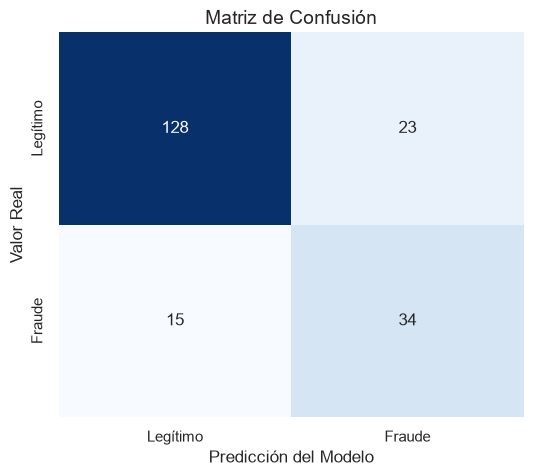

In [9]:
# 1. Reporte de Clasificación
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred))

# 2. Métrica ROC-AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"Área Bajo la Curva ROC (ROC-AUC): {auc_score:.4f}")

# 3. Gráfico de Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Legítimo", "Fraude"], yticklabels=["Legítimo", "Fraude"])
plt.title("Matriz de Confusión")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

### Curva ROC (Receiver Operating Characteristic)
Visualicemos la capacidad de discriminación del modelo.

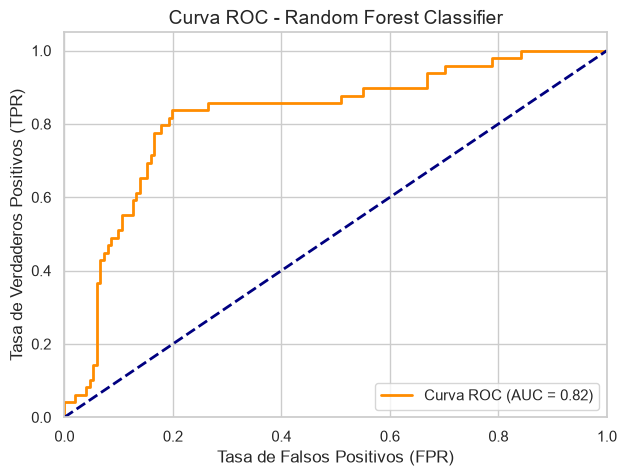

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest Classifier')
plt.legend(loc="lower right")
plt.show()

### Importancia de las Variables (Feature Importance)
¿Cuáles son los principales inductores o indicadores de fraude según nuestro Random Forest?

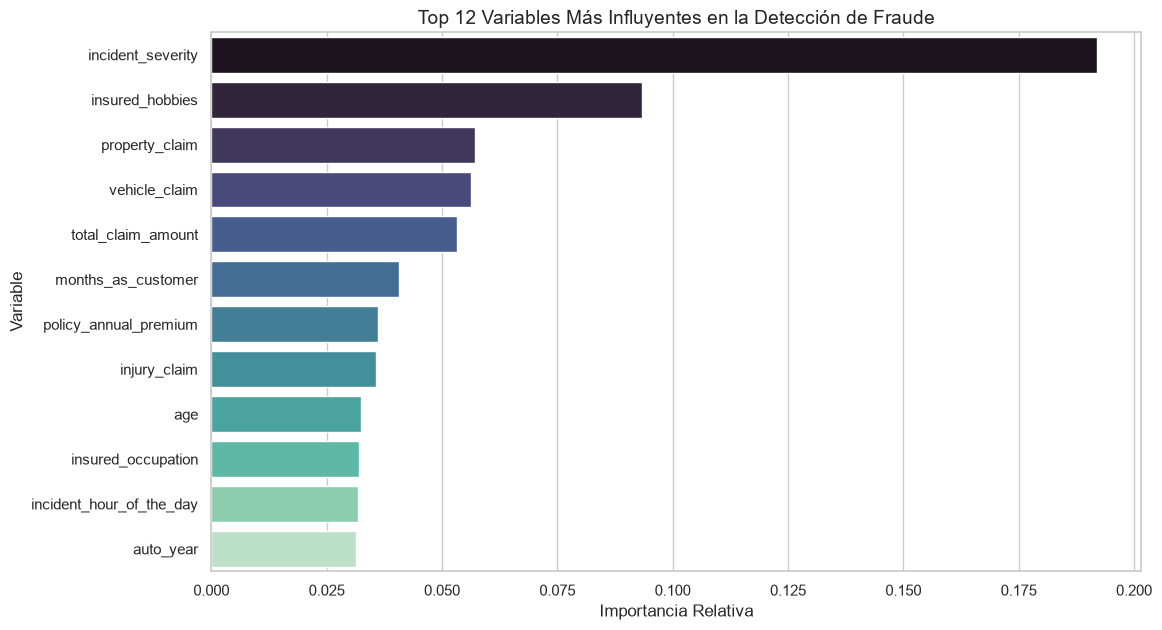

In [11]:
# Obtener importancia de las variables
importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

# Crear DataFrame ordenado
feat_imp_df = pd.DataFrame({
    'Variable': [features[i] for i in indices],
    'Importancia': [importances[i] for i in indices]
})

# Graficar las 12 variables más importantes
plt.figure(figsize=(12, 7))
sns.barplot(x="Importancia", y="Variable", hue="Variable", data=feat_imp_df.head(12), palette="mako", legend=False)
plt.title("Top 12 Variables Más Influyentes en la Detección de Fraude")
plt.xlabel("Importancia Relativa")
plt.ylabel("Variable")
plt.show()

## 🧠 Conclusiones y Plan de Acción de Negocio

1. **Inductores Críticos de Fraude**: La variable **`incident_severity`** (gravedad del incidente) es por amplio margen la más relevante para el modelo (~19% de la importancia total). Le siguen **`insured_hobbies`** (~9%) y las variables monetarias **`property_claim`**, **`vehicle_claim`** y **`total_claim_amount`** (~5-6% cada una).
2. **Comportamiento en Siniestros**: Los siniestros reportados como daños mayores (*Major Damage*) ameritan una auditoría automática, ya que estadísticamente concentran la mayor densidad de fraudes.
3. **Valor del Modelo**: Utilizar un modelo predictivo como *Random Forest* permite pre-clasificar los reclamos con un score probabilístico (**ROC-AUC = 0.82** en el set de prueba; recall de fraude 0.69 con precisión 0.60). Esto permite canalizar los casos sospechosos de alto valor directamente al equipo de investigación especializada, reduciendo los tiempos de aprobación de reclamos legítimos y minimizando los pagos indebidos por fraude.